In [ ]:
import sys

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
from scipy import stats

## Utilities

In [2]:
map_to_range = lambda a, b, c, d, e: (a - b) * (e - d) / (c - b) + d

## Loading the Data

The subset of the dataset used for validation ($n = 50$) is loaded from disk.

In [3]:
samples = pd.read_csv("data/validation_set.csv")

## Automatic Labelling

This sections sets up and performs the automatic labelling of the validation set.

### Defining Automatic Labellers

Here, the automatic labellers are defined and wrapped for convenience.

In [78]:
sys.path.append("automatic-labellers/Handwriting-Quality-Assessor")
sys.path.append("automatic-labellers/claude")

#### Auto Labeller 01 - _Handwriting Quality Assessor_

S5-Team-Workspace/Handwriting-Quality-Assessor. (Oct. 10, 2025). Jupyter Notebook. S5-Team-Workspace. Accessed: Apr. 23, 2026. [Online]. Available: https://github.com/S5-Team-Workspace/Handwriting-Quality-Assessor

In [54]:
# Automatic Labeller 01

from vae_handwriting_model import HandwritingQualityAssessor

hq_vae_model_path = "automatic-labellers/Handwriting-Quality-Assessor/models/handwriting_vae.pth"

def _load_hq_vae(path: str):
  assessor = HandwritingQualityAssessor()
  try:
      assessor.load_model(path)
      assessor.model_trained = True
      return assessor
  except Exception:
      return None

assessor01 = _load_hq_vae(hq_vae_model_path)
if assessor01 is None:
    st.error(f"Could not load VAE handwriting quality model from {hq_vae_model_path}")

def automatic_labeller_01(img: Image) -> (float, float):
  res = assessor01.assess_handwriting_quality(img)
  if "error" in res:
      res["error"]
  else:
      q = res["overall_quality_score"]
      cat = res["quality_category"]
      return q, cat

#### Auto Labeller 02 - [Paddle OCR](https://www.paddleocr.ai/latest/en/index.html)

In [43]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
  lang="en",
  use_doc_orientation_classify=False,
  use_doc_unwarping=False,
  use_textline_orientation=False,
)

def automatic_labeller_02(img: Image, acc_df = None):
  numpydata = np.asarray(img)
  result = ocr.predict(numpydata)

  for res in result:
    df = pd.json_normalize(res)

    temp = pd.concat([acc_df, df], ignore_index=False)
    acc_df.drop(acc_df.index[0:], inplace=True)
    acc_df[temp.columns] = temp

    return res

/Users/rudolphmax/Documents/studium/BA/Handwriting Quality Assessment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rudolphmax/Documents/studium/BA/Handwriting Quality Assessment/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/rudolphmax/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Us

#### Auto Labeller 03 - Claude Sonnet 4.6

Remember to insert an API key below!

In [ ]:
import anthropic
from score_handwriting import score_image

client = anthropic.Anthropic(api_key="")

def automatic_labeller_03(img_path: str):
    res = score_image(client, Path(img_path))
    df = pd.json_normalize(res, record_prefix="auto_03.")

    return df


### Labelling

In [ ]:
autolabels = samples.copy(deep=True)[["Num", "Filename"]]

In [ ]:
def autolabel(row, labellers: list[int] = [1, 2, 3]):
  img = Image.open(row["Filename"]).convert('RGB')
  img = ImageOps.exif_transpose(img)

  index = []
  data = []

  if (1 in labellers):
    data.append(automatic_labeller_01(img)[0])
    index.append("auto_01")
  
  if (2 in labellers):
    data.append(automatic_labeller_02(img))
    index.append("auto_02")
  
  if (3 in labellers):
    res = automatic_labeller_03(row["Filename"])
    
    data.append([
      res["auto_03.overall"].values[0],
      res["auto_03.legibility"].values[0],
      res["auto_03.letter_consistency"].values[0],
      res["auto_03.line_alignment"].values[0],
      res["auto_03.spacing"].values[0],
    ])

    index.append([
      "auto_03.overall",
      "auto_03.legibility",
      "auto_03.letter_consistency",
      "auto_03.line_alignment",
      "auto_03.spacing",
    ])

  return pd.Series(data, index=index)

# Running the auto-labellers for all samples in the validation set
autolabels = pd.concat([
    autolabels,
    autolabels.apply(autolabel, axis=1)
  ],
  axis=1
)

# Saving the generated autolabels to disk
autolabels.to_csv("data/autolabels.csv", index=False)

### TODO: Remove thsi temporary function

In [70]:
def autolabel2(row):
  img = Image.open(row["Filename"]).convert('RGB')
  img = ImageOps.exif_transpose(img)

  res = automatic_labeller_03(row["Filename"])

  return pd.Series([
    res["auto_03.overall"].values[0],
    res["auto_03.legibility"].values[0],
    res["auto_03.letter_consistency"].values[0],
    res["auto_03.line_alignment"].values[0],
    res["auto_03.spacing"].values[0],
  ], index=[
    "auto_03.overall",
    "auto_03.legibility",
    "auto_03.letter_consistency",
    "auto_03.line_alignment",
    "auto_03.spacing",
  ])

  return row

# Running the auto-labellers for all samples in the validation set
autolabels = pd.concat([
    autolabels,
    autolabels.apply(autolabel2, axis=1)
  ],
  axis=1
)

# Saving the generated autolabels to disk
autolabels.to_csv("data/autolabels.csv", index=False)

KeyboardInterrupt: 

## Data Analysis

### Data Preprocessing

The scores (both automatic and human) are loaded and transformed for meaningful evaluation. This includes scaling a range of 0-100 and aggregating.

In [95]:
autolabels = pd.read_csv("data/autolabels.csv")
human_labels = pd.read_csv("data/validation_labels.csv")

Transforming the human scores (HLS and Ziviani).

In [116]:
# Aggregate HLS score
human_labels["HLS Score"] = human_labels.loc[:, ["Legibility", "Effort", "Layout", "Letter Formation", "Alteration"]].sum(axis=1)

# Aggregate Ziviani Score
human_labels["Horizontal Alignment"] = 1 - human_labels["Horizontal Alignment"]

zivVertMeanWeight = 0.6
zivVertStdWeight = 1 - zivVertMeanWeight
zivVertRaw = (human_labels["Vertical Alignment Std"] + human_labels["Vertical Alignment Mean"])
human_labels["Vertical Alignment"] = 1 - (zivVertRaw - zivVertRaw.min()) / (zivVertRaw.max() - zivVertRaw.min())

human_labels["Ziv Score"] = human_labels.loc[:, ["Formation Ziv", "Horizontal Alignment", "Vertical Alignment"]].mean(axis=1)

Transforming the auto scores (auto_03 aka Claude).

In [111]:
autolabels["auto_03"] = autolabels[["auto_03.overall", "auto_03.legibility", "auto_03.letter_consistency", "auto_03.line_alignment", "auto_03.spacing"]].mean(axis=1)

Joining the human and auto-generated scores, scaling and aggregating

In [112]:
joined = human_labels.join(autolabels.set_index("Num"), on="Num", lsuffix="_caller", rsuffix="_other")
joined = joined[["Num", "Filename_caller", "HLS Score", "Ziv Score", "auto_01", "auto_02", "auto_03"]]
joined = joined.rename(columns={ "Filename_caller": "Filename" })

# Reverse HLS Score and map to 0-100
joined["HLS Score"] = map_to_range(joined["HLS Score"], 25, 5, 0, 100)
joined["Ziv Score"] = joined["Ziv Score"] * 100
joined["human_mean"] = joined[["HLS Score", "Ziv Score"]].mean(axis=1)

joined["auto_02"] = joined["auto_02"] * 100
joined["auto_03"] = joined["auto_03"] * 10
joined["auto_mean"] = joined[["auto_01", "auto_02", "auto_03"]].mean(axis=1)

joined

,Num,Filename,HLS Score,Ziv Score,auto_01,auto_02,auto_03,human_mean,auto_mean
0,412,data/dataset/eng_EU_229.jpg,95.0,60.687343,34.591328,89.458175,70.0,77.843671,64.683168
1,1297,data/dataset/f04-100.png,90.0,73.283657,27.608215,93.788957,74.0,81.641828,65.132391
2,603,data/dataset/eng_NA_118.jpg,100.0,70.128739,28.305027,91.747967,70.0,85.064369,63.350998
3,204,data/dataset/eng_EU_015.jpg,100.0,51.095985,34.396433,93.999776,60.0,75.547992,62.798736
4,2015,data/dataset/n04-190.png,85.0,66.567688,27.611314,88.307654,70.0,75.783844,61.972989
5,861,data/dataset/b03-114.png,75.0,61.465345,27.636756,91.638824,66.0,68.232672,61.758526
6,1757,data/dataset/k04-093.png,75.0,62.546585,27.582702,92.841743,68.0,68.773293,62.808148
7,970,data/dataset/c03-007b.png,75.0,59.091406,27.668597,79.416522,72.0,67.045703,59.695040
8,2040,data/dataset/p01-147.png,95.0,77.246673,27.571319,90.970893,70.0,86.123337,62.847404
9,0,data/dataset/eng_AF_001.jpg,70.0,44.770651,32.616895,0.000000,58.0,57.385326,30.205632


### Statistical Results

#### Distributions

<Axes: xlabel='HLS Score', ylabel='Count'>

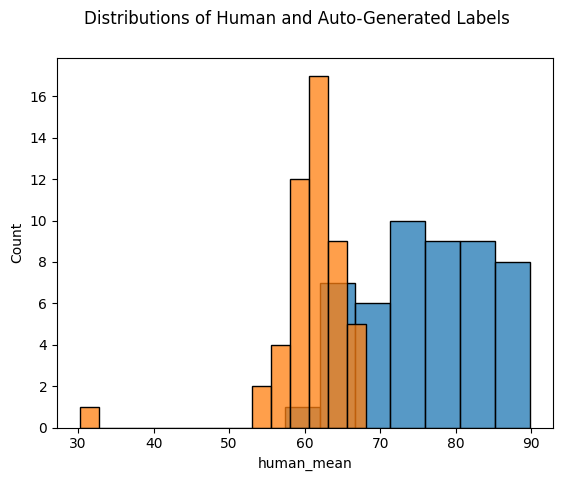

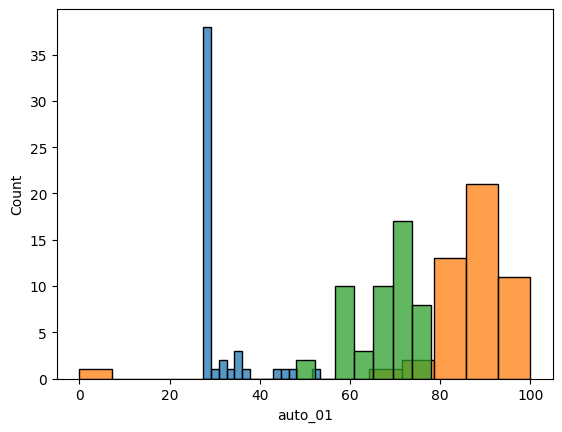

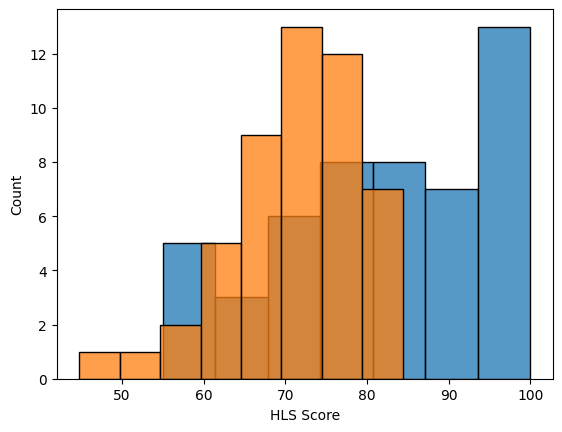

In [113]:
fig, axs = plt.subplots()
fig.suptitle('Distributions of Human and Auto-Generated Labels')
sns.histplot(joined["human_mean"])
sns.histplot(joined["auto_mean"])

fig, axs = plt.subplots()
sns.histplot(joined["auto_01"])
sns.histplot(joined["auto_02"])
sns.histplot(joined["auto_03"])

fig, axs = plt.subplots()
sns.histplot(joined["HLS Score"])
sns.histplot(joined["Ziv Score"])

#### Corellation of the human scores

Spearman's ρ: 0.298
p-value: 0.035


<Axes: xlabel='HLS Score', ylabel='Ziv Score'>

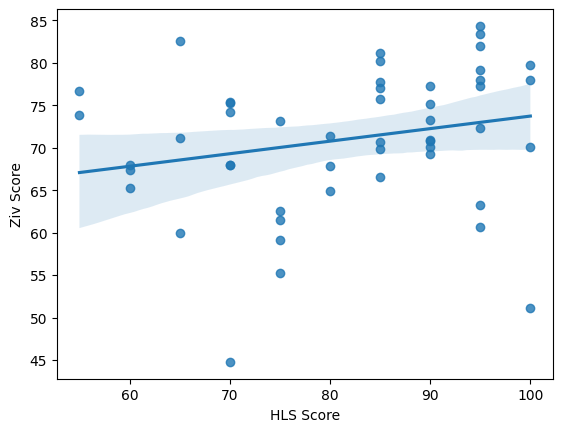

In [120]:
t = joined[-np.isnan(joined["Ziv Score"])]

rho, p_value = stats.spearmanr(t['HLS Score'], t['Ziv Score'])
print(f"Spearman's ρ: {rho:.3f}")
print(f"p-value: {p_value:.3f}")

sns.regplot(x="HLS Score", y="Ziv Score", data=t)

#### Corellation of the auto scores

Spearman's ρ: nan
p-value: nan
Spearman's ρ: nan
p-value: nan
Spearman's ρ: -0.257
p-value: 0.072


<Axes: xlabel='auto_01', ylabel='auto_03'>

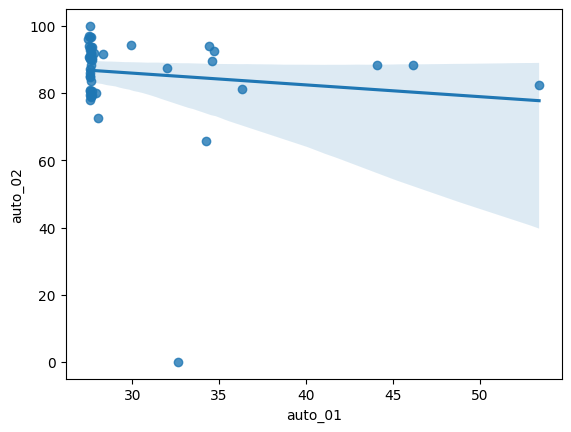

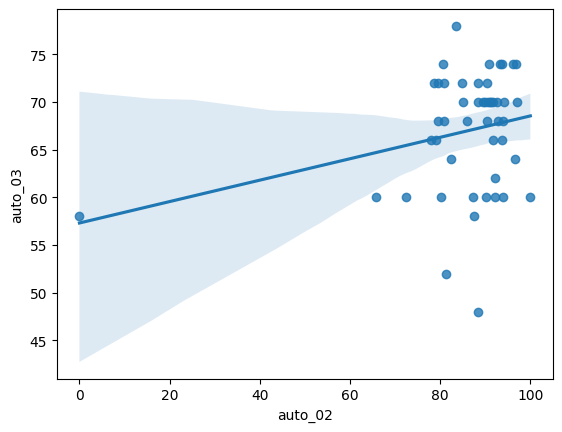

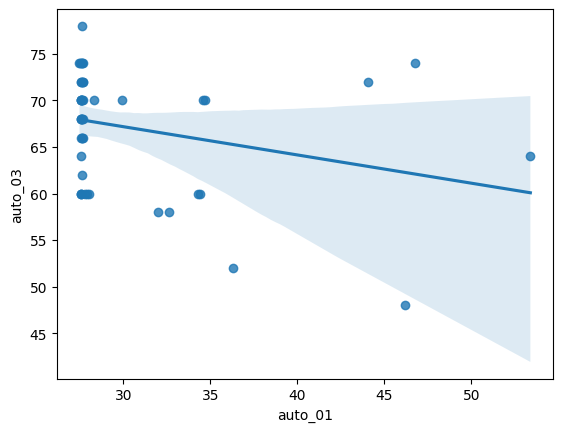

In [123]:
# auto_01 and auto_02
fig, axs = plt.subplots()
rho, p_value = stats.spearmanr(joined['auto_01'], t['auto_02'])
print(f"Spearman's ρ: {rho:.3f}")
print(f"p-value: {p_value:.3f}")

sns.regplot(x="auto_01", y="auto_02", data=t)

# auto_02 and auto_03
fig, axs = plt.subplots()
rho, p_value = stats.spearmanr(joined['auto_02'], t['auto_03'])
print(f"Spearman's ρ: {rho:.3f}")
print(f"p-value: {p_value:.3f}")

sns.regplot(x="auto_02", y="auto_03", data=t)

# auto_01 and auto_03
fig, axs = plt.subplots()
rho, p_value = stats.spearmanr(joined['auto_01'], t['auto_03'])
print(f"Spearman's ρ: {rho:.3f}")
print(f"p-value: {p_value:.3f}")

sns.regplot(x="auto_01", y="auto_03", data=t)

#### Corellation of human and auto scores

Spearman's ρ: 0.417
p-value: 0.003


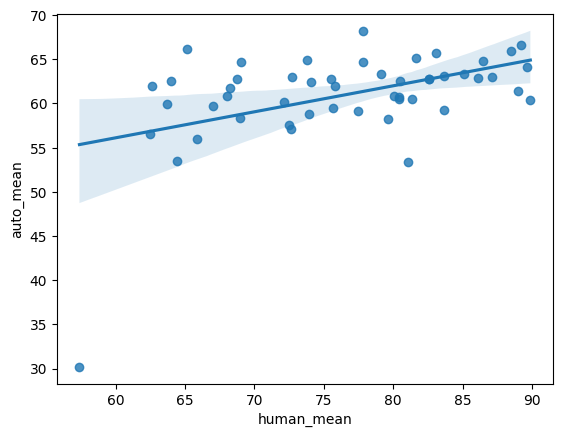

In [127]:
filtered_auto_mean = joined['auto_02'] > 0
sns.regplot(x="human_mean", y="auto_mean", data=joined)
# sns.regplot(x="human_mean", y="auto_mean", data=joined[filtered_auto_mean])

rho, p_value = stats.spearmanr(joined[["human_mean", "auto_mean"]])
# rho, p_value = stats.spearmanr(joined[filtered_auto_mean][["human_mean", "auto_mean"]])
print(f"Spearman's ρ: {rho:.3f}")
print(f"p-value: {p_value:.3f}")